## This notebook builds microbial communities from FluRICo features and performs pseudotime trajectory analysis for dynamic and structural groups.

In [1]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from core import pesudotime

import tqdm
from joblib import load,dump
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tqdm import tqdm
np.random.seed(888)


### Data input

In [2]:
df_mb = pd.read_csv('data/microbe_train.csv',index_col=0)
df_mt = pd.read_csv('data/metabolite_train.csv',index_col=0)

In [3]:
df_mb = np.log1p(df_mb)
df_mt = np.log1p(df_mt)

In [4]:
tax = pd.read_csv('data/taxonomy.csv')
full_name_dic = {}
for i in range(len(tax)):
    full_name_dic[tax['ID'][i]] = tax['Taxonomy'][i]

In [5]:
# Load feature list
mb_dy_list = load('results/flurico_results/mb_dy_list.data')
mb_st_list = load('results/flurico_results/mb_st_list.data')


In [6]:

def cal_community(df, feature_list, label):
    df_comm = df[feature_list].loc[label]
    df_comm_distance = df_comm.corr(method='spearman') 
    
    df_comm_distance = df_comm_distance.fillna(0)
    np.fill_diagonal(df_comm_distance.values, 1.0)
    
    
    df_comm_distance.columns = df_comm.columns
    df_comm_distance.index = [i+'_'+label for i in df_comm_distance.columns]
    return df_comm_distance
def build_communities(df, dy_features, st_features, labels=('HC', 'MIA', 'IA')):
    result = {}

    for group_name, feature_list in {'dy': dy_features, 'st': st_features}.items():
        group_comm = {
            label: cal_community(df, feature_list, label)
            for label in labels
        }
        group_comm['all'] = pd.concat([group_comm[label] for label in labels])
        result[group_name] = group_comm

    return result

In [7]:
mb_comm = build_communities(df_mb, mb_dy_list, mb_st_list)

### Dynamic group trajectory


data_type: microbe
matrix type: symmetric / stacked correlation matrices
data shape: 843 rows x 281 columns

✓ Parsed group labels from df.index without relying on row order.
  group counts: {'HC': 281, 'MIA': 281, 'IA': 281}
✓ Self-corr masking: matched 843/843 rows (100.0%), set to 0.0.
Parsing taxonomy at level: f__ ...
Figure 3 mode B: automatically selecting the Top 10 most abundant taxa.
Computing dimensionality reduction and pseudotime...
Note: using the raw matrix to compute neighbors (PCA skipped).
Computing Diffusion Map...
✓ Root strategy: using the centroid-nearest sample in group HC (index: 122).
  -> sample: g__Carboxydocella;s__Carboxydocella sporoproducens_HC | Entity: g__Carboxydocella;s__Carboxydocella sporoproducens
Computing PAGA topology...
✓ PAGA: removed the direct HC-IA edge.
✓ Figure 4: computing pseudotime change (HC -> IA) using the abs_delta metric.
group                                       HC        IA       MIA  \
taxonomy                               

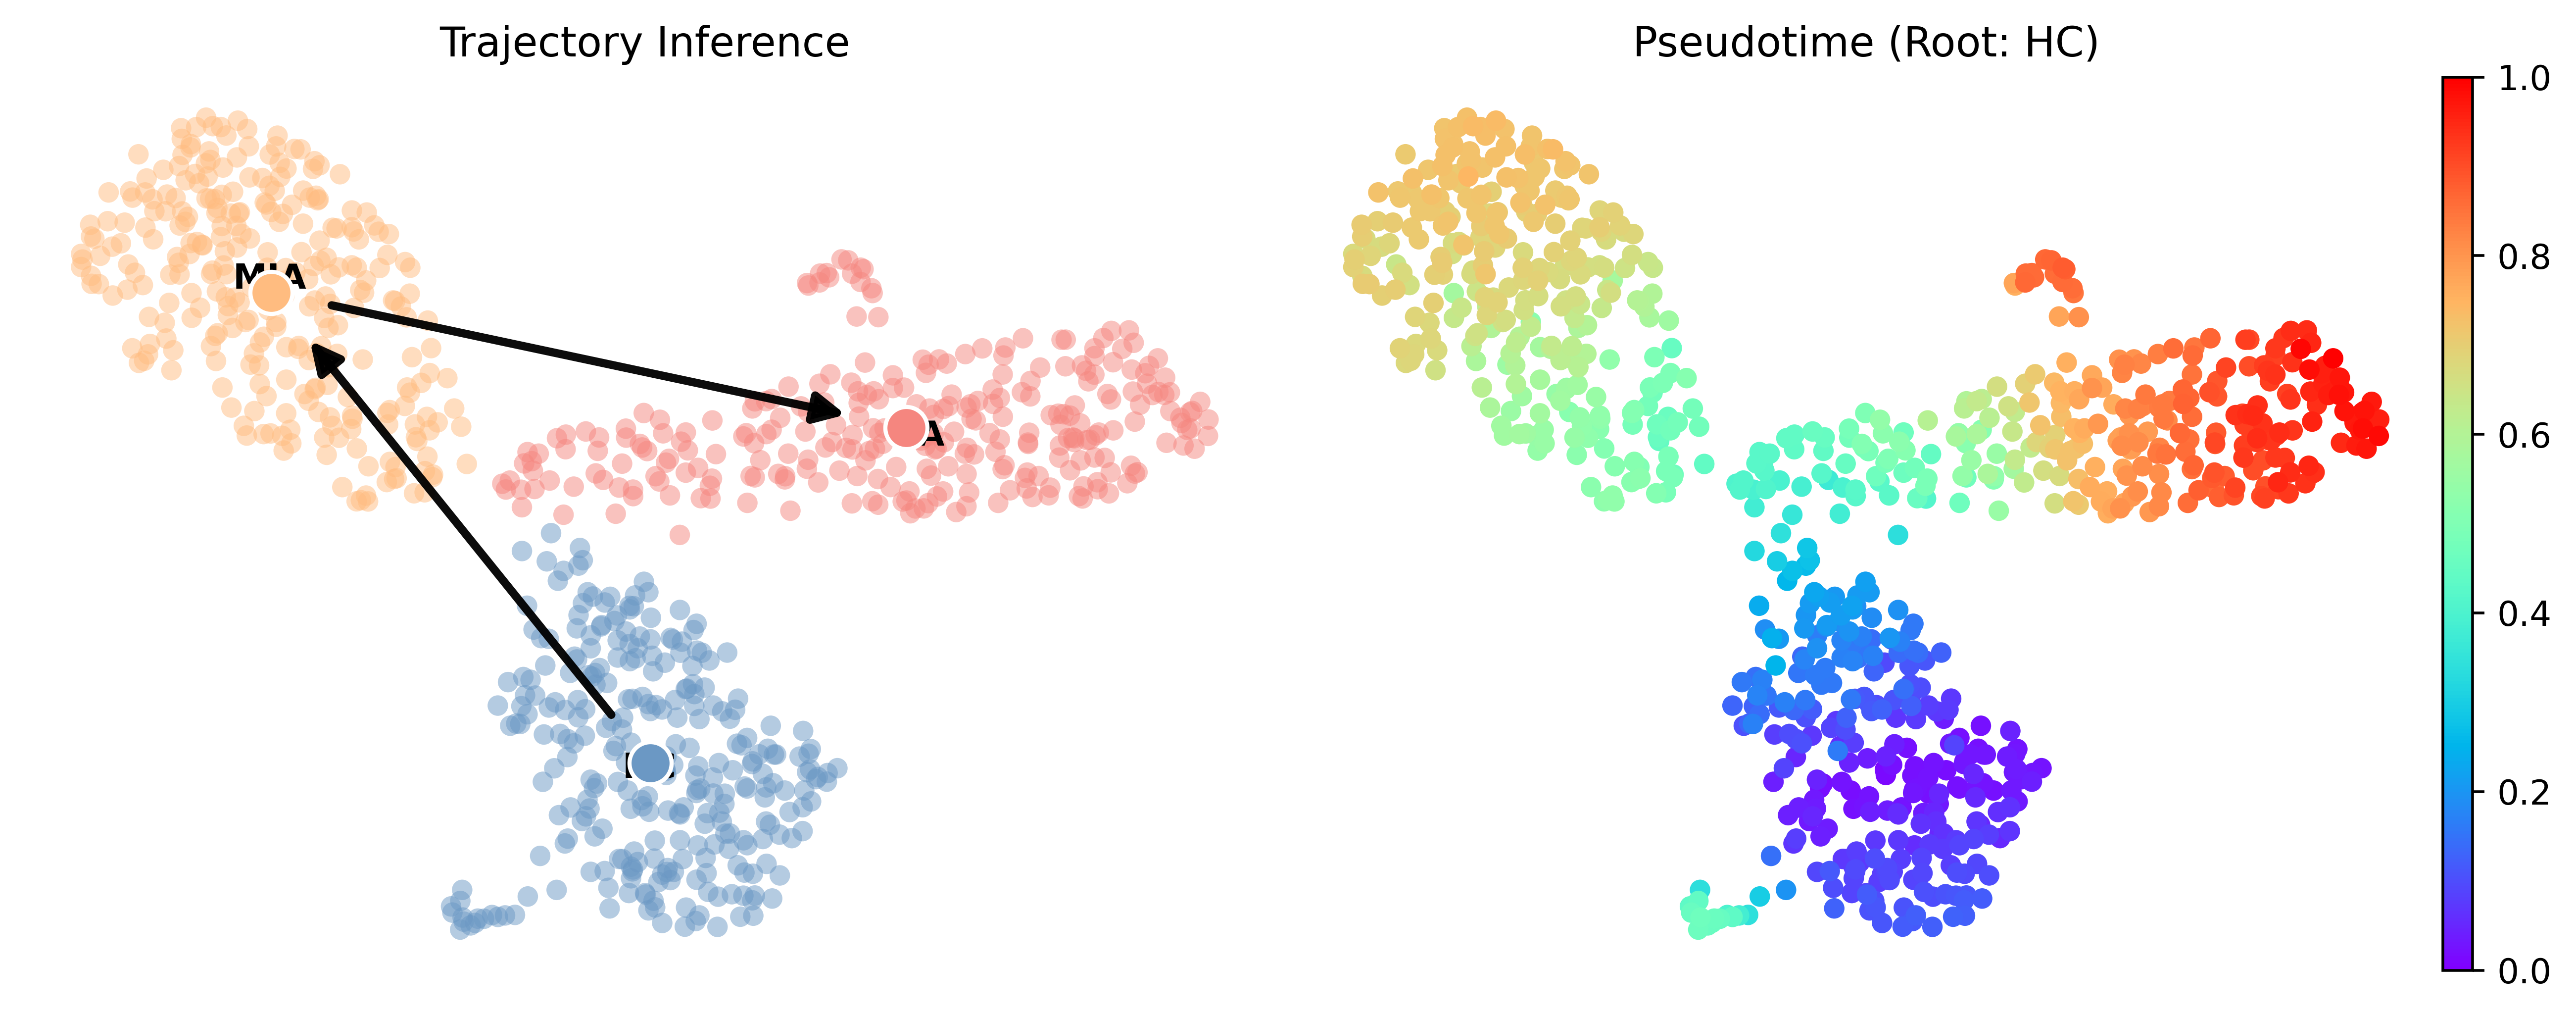


✓ Analysis completed.



In [8]:
dy_adata,dy_mb_topchange = pesudotime.run_trajectory_analysis_ultimate(mb_comm['dy']['all'],full_name_dic,  
                                root_strategy='centroid',use_pca=False,change_tax_level='s__',
                                                cmap='rainbow',
                                                top_n = 10,
                                           savepath = None)

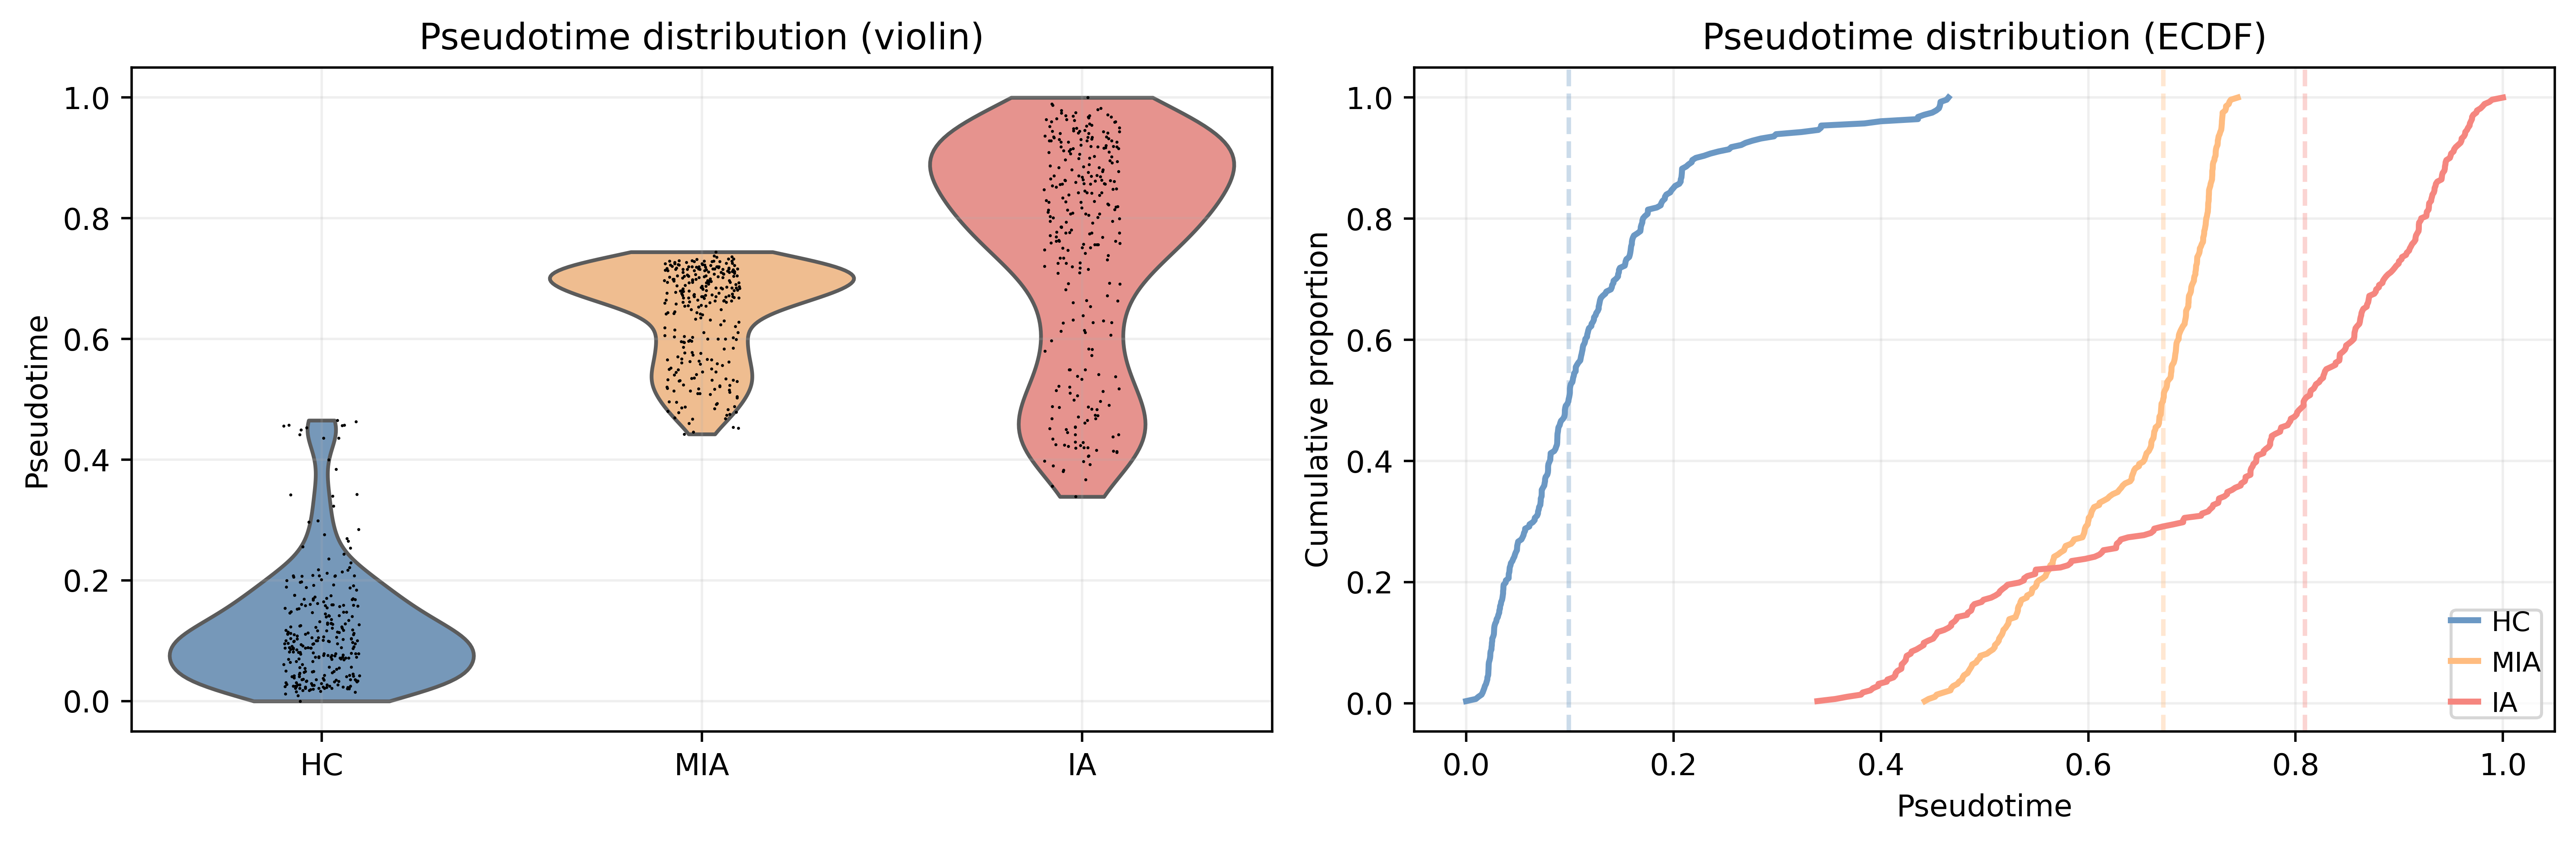

In [9]:
pesudotime.plot_pseudotime_violin_and_ecdf(dy_adata, dpi=500,  savepath = None)

### Structural group trajectory modeling


data_type: microbe
matrix type: symmetric / stacked correlation matrices
data shape: 747 rows x 249 columns

✓ Parsed group labels from df.index without relying on row order.
  group counts: {'HC': 249, 'MIA': 249, 'IA': 249}
✓ Self-corr masking: matched 747/747 rows (100.0%), set to 0.0.
Parsing taxonomy at level: f__ ...
Figure 3 mode B: automatically selecting the Top 10 most abundant taxa.
Computing dimensionality reduction and pseudotime...
Note: using the raw matrix to compute neighbors (PCA skipped).
Computing Diffusion Map...
✓ Root strategy: using the centroid-nearest sample in group HC (index: 20).
  -> sample: g__Pseudobutyrivibrio;s__Pseudobutyrivibrio sp. C4_HC | Entity: g__Pseudobutyrivibrio;s__Pseudobutyrivibrio sp. C4
Computing PAGA topology...
✓ PAGA: removed the direct HC-IA edge.
✓ Figure 4: computing pseudotime change (HC -> IA) using the abs_delta metric.
group                                        HC        IA       MIA  \
taxonomy                               

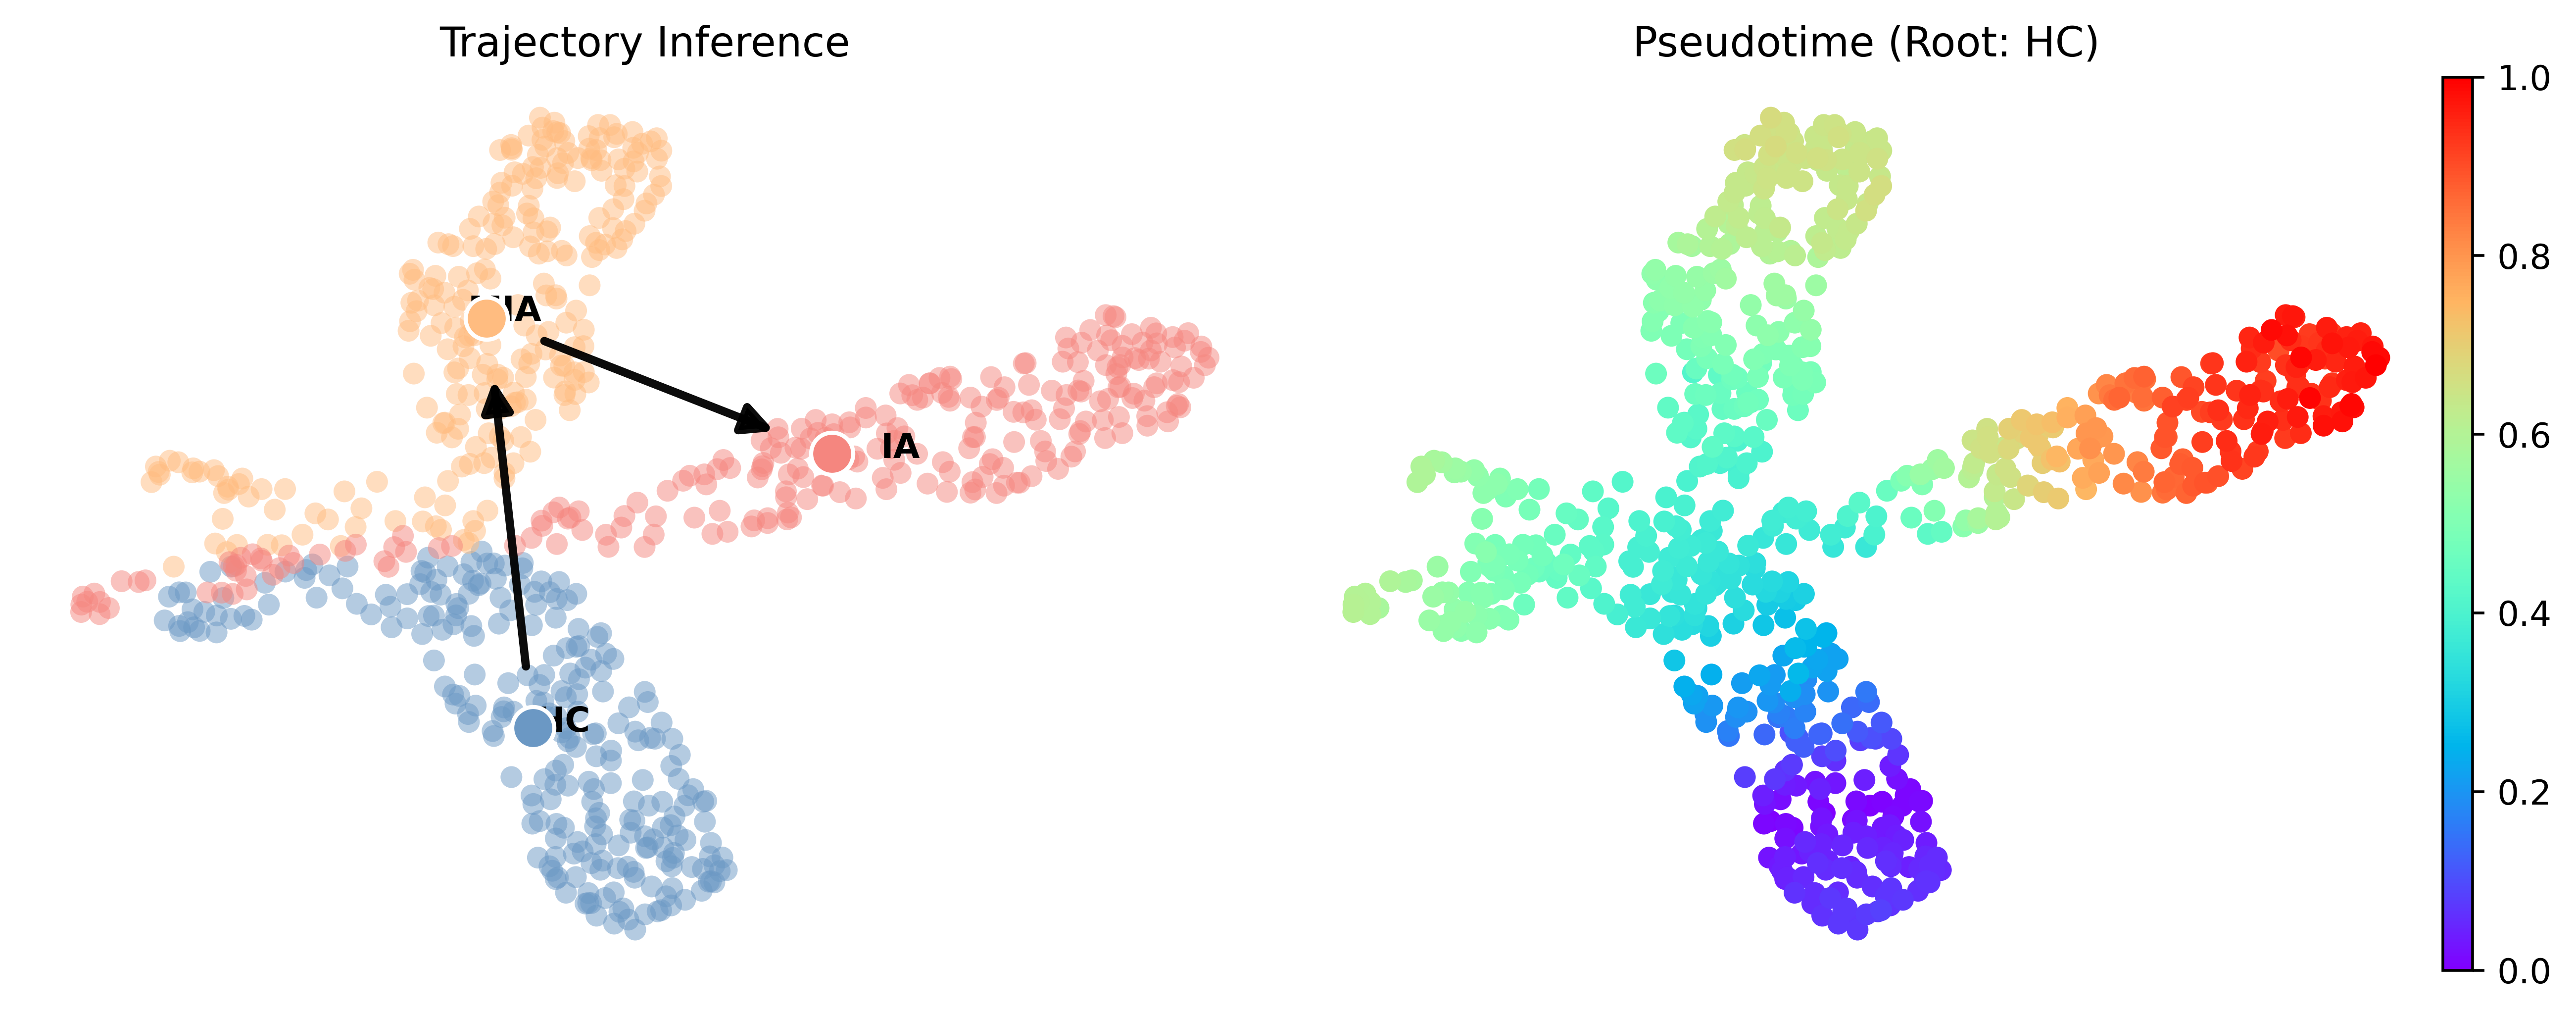


✓ Analysis completed.



In [10]:
st_adata,st_mb_topchange = pesudotime.run_trajectory_analysis_ultimate(mb_comm['st']['all'],full_name_dic,  
                                root_strategy='centroid',use_pca=False,change_tax_level='s__',
                                                cmap='rainbow',
                                                top_n = 10,
                                           savepath = None)

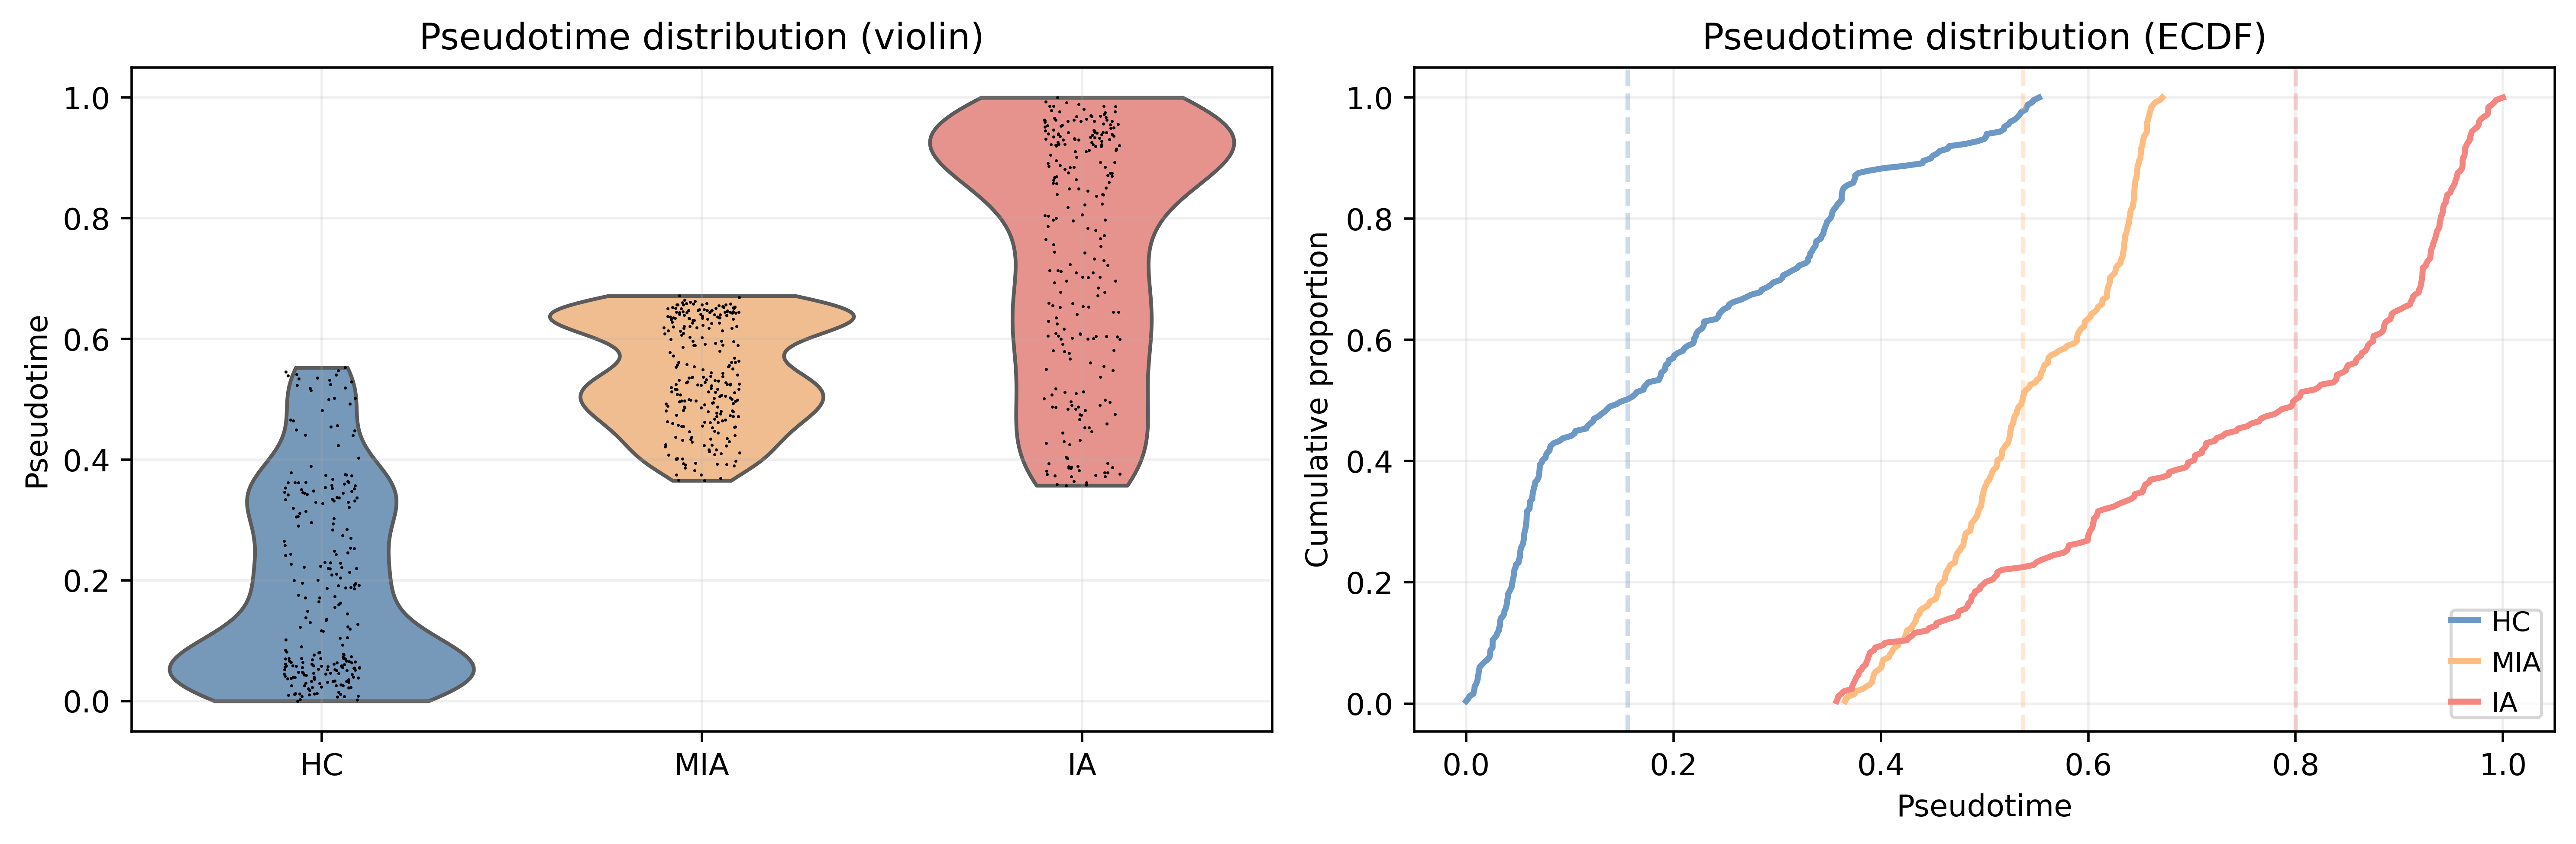

In [11]:
pesudotime.plot_pseudotime_violin_and_ecdf(st_adata, dpi=500,  savepath = None)

### Top 20 Pesudotime of microbes (MIA and IA)

In [12]:
def get_common_elements(*lists):

    if not lists:
        return []

    common_set = set(lists[0])

    if len(lists) > 1:
        common_set = common_set.intersection(*lists[1:])
        
    return list(common_set)
    
def find_middle (df,d_n=20):

    _df_mia = df.copy().sort_values(by=['MIA'])
    _df_ia = df.copy().sort_values(by=['IA'])

    _mia_top = list(_df_mia[:d_n].index)
    _ia_top = list(_df_ia[:d_n].index)
    overlap = get_common_elements(_mia_top,_ia_top)
    return overlap

In [13]:
find_middle(dy_mb_topchange)

['s__Acidithiobacillus ferrivorans',
 's__Beauveria bassiana',
 's__Enterococcus sp. HMSC064A12',
 's__Thiothrix nivea',
 's__Yersinia aldovae',
 's__Escherichia virus Lambda',
 's__Burkholderia dolosa']

In [14]:
find_middle(st_mb_topchange)

['s__Rufibacter sp. DG15C',
 's__Desulfomicrobium apsheronum',
 's__Lactobacillus paracasei']